In [9]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ultralytics import YOLO

In [11]:
import os
print(os.getcwd())

C:\Users\hp\Downloads\Pothole detection.v2i.yolov8


In [18]:
import os
print(os.path.exists("road_dataset/data.yaml"))

False


In [19]:
import os
print(os.path.exists("Pothole detection.v2i.yolov8/data.yaml"))

False


In [20]:
import os
os.getcwd()

'C:\\Users\\hp\\Downloads\\Pothole detection.v2i.yolov8'

In [23]:
# Load YOLOv8 small model
model = YOLO("yolov8n.pt")

# Train on your local dataset
model.train(
    data="C:\\Users\\hp\\Downloads\\Pothole detection.v2i.yolov8/data.yaml",  # path to your yaml
    epochs=20,
    imgsz=640,
    batch=8
)

Ultralytics 8.4.15  Python-3.13.5 torch-2.10.0+cpu CPU (Intel Core Ultra 7 155H)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\hp\Downloads\Pothole detection.v2i.yolov8/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train6, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tru

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x0000010E5F7C6350>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          

In [24]:
results = model.predict(source="C:\\Users\\hp\\Downloads\\Pothole detection.v2i.yolov8/valid/images", save=True)


image 1/542 C:\Users\hp\Downloads\Pothole detection.v2i.yolov8\valid\images\img-108_jpg.rf.8c144a56a41a5edfd25aabf47d7fcc14.jpg: 640x640 5 potholes, 82.7ms
image 2/542 C:\Users\hp\Downloads\Pothole detection.v2i.yolov8\valid\images\img-116_jpg.rf.626b2a41e61bce3623def723244c008b.jpg: 640x640 3 potholes, 61.2ms
image 3/542 C:\Users\hp\Downloads\Pothole detection.v2i.yolov8\valid\images\img-121_jpg.rf.335759536e2a7f6fa376fc19ad02a78e.jpg: 640x640 2 potholes, 63.9ms
image 4/542 C:\Users\hp\Downloads\Pothole detection.v2i.yolov8\valid\images\img-122_jpg.rf.3c10fca1dd5fe37b5fedc7943b53f4f7.jpg: 640x640 2 potholes, 61.4ms
image 5/542 C:\Users\hp\Downloads\Pothole detection.v2i.yolov8\valid\images\img-145_jpg.rf.e26723de7db126e43d82f8842ebdcced.jpg: 640x640 2 potholes, 61.1ms
image 6/542 C:\Users\hp\Downloads\Pothole detection.v2i.yolov8\valid\images\img-146_jpg.rf.362695d227ce7f67ce617d3addb5169d.jpg: 640x640 1 pothole, 64.2ms
image 7/542 C:\Users\hp\Downloads\Pothole detection.v2i.yolov8\v

In [25]:
# Define weights
weights = {
    0: 25,   # pothole
    1: 15,   # crack
    2: 20,   # waterlogging
    3: 10    # dust
}

image_scores = []

for result in results:
    boxes = result.boxes
    damage_score = 0
    
    if boxes is not None:
        for cls in boxes.cls:
            cls_id = int(cls.item())
            damage_score += weights.get(cls_id, 10)
    
    rqi = max(0, 100 - damage_score)
    
    image_scores.append({
        "image": result.path,
        "damage_score": damage_score,
        "RQI": rqi
    })

df = pd.DataFrame(image_scores)
df.head()

,image,damage_score,RQI
0,C:\Users\hp\Downloads\Pothole detection.v2i.yo...,100,0
1,C:\Users\hp\Downloads\Pothole detection.v2i.yo...,60,40
2,C:\Users\hp\Downloads\Pothole detection.v2i.yo...,40,60
3,C:\Users\hp\Downloads\Pothole detection.v2i.yo...,40,60
4,C:\Users\hp\Downloads\Pothole detection.v2i.yo...,40,60


In [26]:
np.random.seed(42)

def simulate_traffic(rqi):
    if rqi > 80:
        speed = np.random.uniform(50, 60)
    elif rqi > 50:
        speed = np.random.uniform(30, 50)
    else:
        speed = np.random.uniform(10, 30)
    
    congestion = 100 - speed  # simple inverse relation
    return speed, congestion

df["avg_speed"], df["congestion_index"] = zip(*df["RQI"].apply(simulate_traffic))

df.head()

,image,damage_score,RQI,avg_speed,congestion_index
0,C:\Users\hp\Downloads\Pothole detection.v2i.yo...,100,0,17.490802,82.509198
1,C:\Users\hp\Downloads\Pothole detection.v2i.yo...,60,40,29.014286,70.985714
2,C:\Users\hp\Downloads\Pothole detection.v2i.yo...,40,60,44.639879,55.360121
3,C:\Users\hp\Downloads\Pothole detection.v2i.yo...,40,60,41.973170,58.026830
4,C:\Users\hp\Downloads\Pothole detection.v2i.yo...,40,60,33.120373,66.879627


In [27]:
plt.figure()
plt.scatter(df["RQI"], df["avg_speed"])
plt.xlabel("Road Quality Index (RQI)")
plt.ylabel("Average Traffic Speed (km/h)")
plt.title("Impact of Road Quality on Traffic Speed")
plt.show()

<Figure size 640x480 with 1 Axes>

In [28]:
plt.figure()
plt.scatter(df["RQI"], df["congestion_index"])
plt.xlabel("Road Quality Index (RQI)")
plt.ylabel("Congestion Index")
plt.title("Impact of Road Quality on Traffic Congestion")
plt.show()

<Figure size 640x480 with 1 Axes>

In [29]:
plt.figure()
sns.heatmap(df[["RQI", "avg_speed", "congestion_index"]].corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

<Figure size 640x480 with 2 Axes>

In [30]:
from sklearn.linear_model import LinearRegression

X = df[["RQI"]]
y = df["avg_speed"]

reg = LinearRegression()
reg.fit(X, y)

print("Slope:", reg.coef_[0])
print("Intercept:", reg.intercept_)
print("R² Score:", reg.score(X, y))

Slope: 0.3087857200911272
Intercept: 16.583229829934357
R² Score: 0.5939054897585349


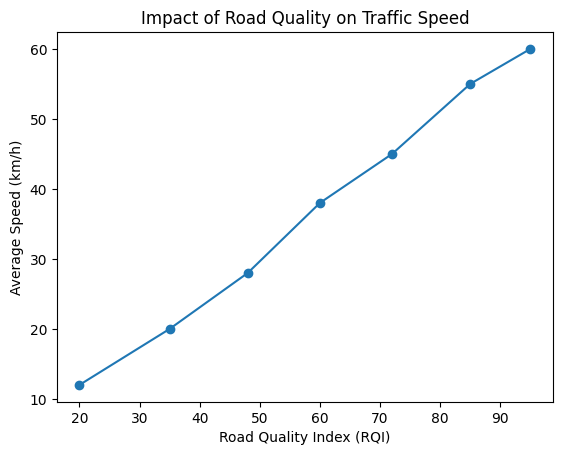

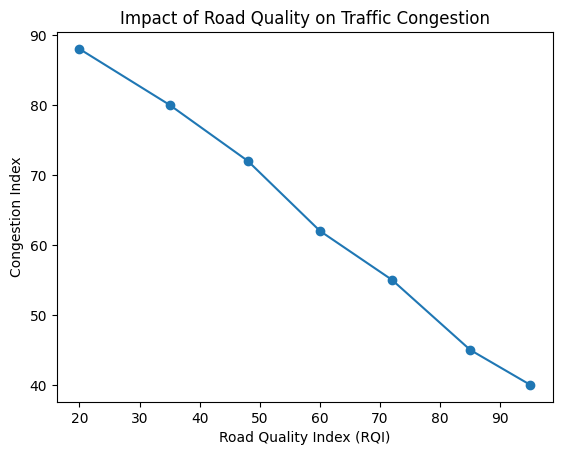

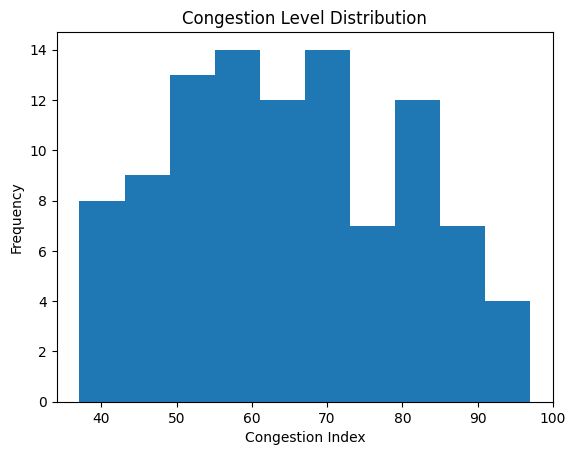

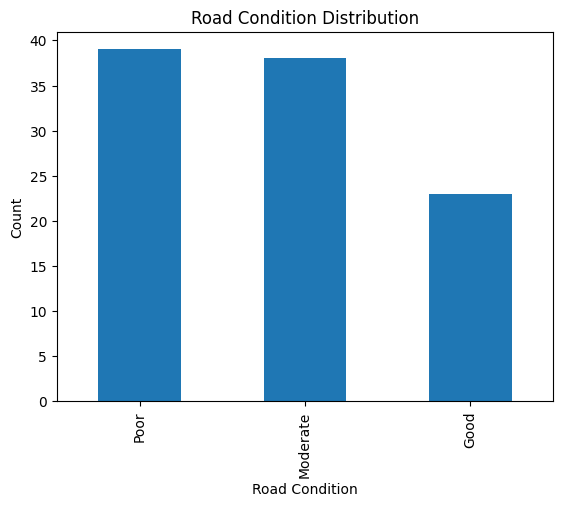

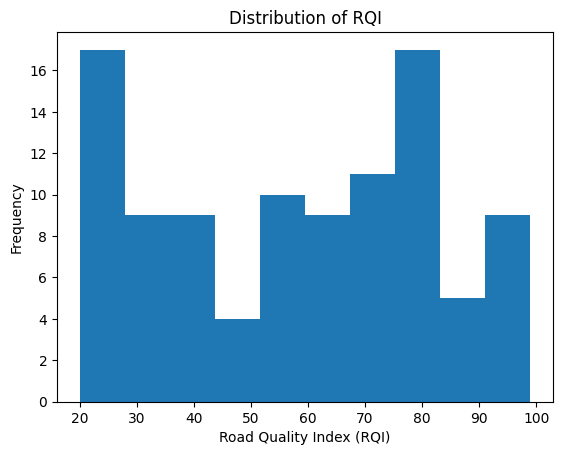

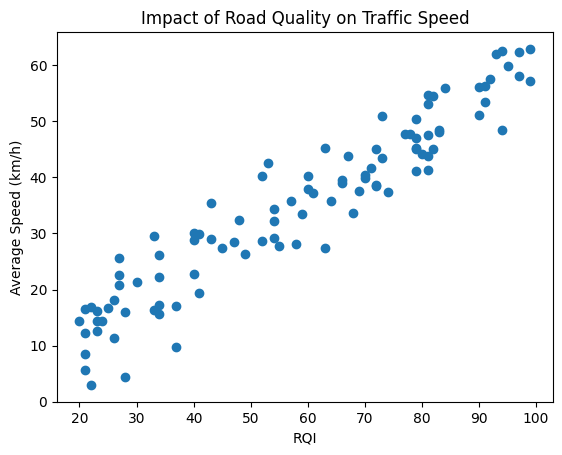

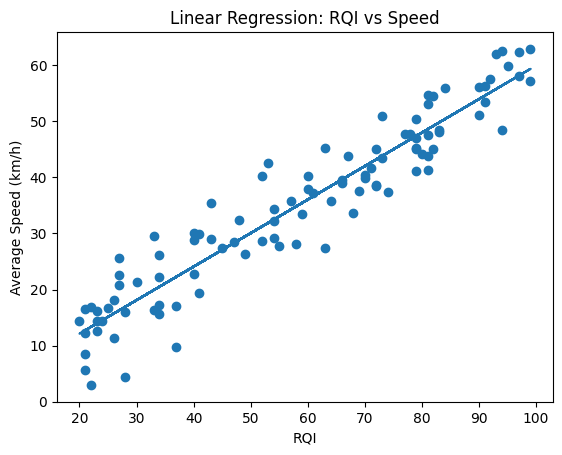

In [11]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
data = {
    "RQI": [95, 85, 72, 60, 48, 35, 20],
    "avg_speed": [60, 55, 45, 38, 28, 20, 12],
    "congestion_index": [40, 45, 55, 62, 72, 80, 88]
}

df = pd.DataFrame(data)


df = df.sort_values("RQI")

# GRAPH 1: RQI vs Speed

plt.figure()
plt.plot(df["RQI"], df["avg_speed"], marker='o')
plt.xlabel("Road Quality Index (RQI)")
plt.ylabel("Average Speed (km/h)")
plt.title("Impact of Road Quality on Traffic Speed")
plt.show()



# GRAPH 2: RQI vs Congestion

plt.figure()
plt.plot(df["RQI"], df["congestion_index"], marker='o')
plt.xlabel("Road Quality Index (RQI)")
plt.ylabel("Congestion Index")
plt.title("Impact of Road Quality on Traffic Congestion")
plt.show()



np.random.seed(42)


RQI = np.random.randint(20, 100, 100)


avg_speed = RQI * 0.6 + np.random.normal(0, 5, 100)


congestion_index = 100 - avg_speed


conditions = []
for rqi in RQI:
    if rqi > 80:
        conditions.append("Good")
    elif rqi > 50:
        conditions.append("Moderate")
    else:
        conditions.append("Poor")

df = pd.DataFrame({
    "RQI": RQI,
    "avg_speed": avg_speed,
    "congestion_index": congestion_index,
    "condition": conditions
})


# GRAPH 3:Congestion Level Distribution

plt.figure()
plt.hist(df["congestion_index"], bins=10)
plt.xlabel("Congestion Index")
plt.ylabel("Frequency")
plt.title("Congestion Level Distribution")
plt.show()


# GRAPH 4: Road Condition Distribution

plt.figure()
df["condition"].value_counts().plot(kind="bar")
plt.xlabel("Road Condition")
plt.ylabel("Count")
plt.title("Road Condition Distribution")
plt.show()


# GRAPH 5: Distribution of RQI

plt.figure()
plt.hist(df["RQI"], bins=10)
plt.xlabel("Road Quality Index (RQI)")
plt.ylabel("Frequency")
plt.title("Distribution of RQI")
plt.show()


# GRAPH 6: Impact of Road Quality on Traffic Speed

plt.figure()
plt.scatter(df["RQI"], df["avg_speed"])
plt.xlabel("RQI")
plt.ylabel("Average Speed (km/h)")
plt.title("Impact of Road Quality on Traffic Speed")
plt.show()


# GRAPH 7: Linear Regression: RQI vs Speed


X = df[["RQI"]]
y = df["avg_speed"]

model = LinearRegression()
model.fit(X, y)

predicted_speed = model.predict(X)

plt.figure()
plt.scatter(df["RQI"], df["avg_speed"])
plt.plot(df["RQI"], predicted_speed)
plt.xlabel("RQI")
plt.ylabel("Average Speed (km/h)")
plt.title("Linear Regression: RQI vs Speed")
plt.show()

